# WEDINOS Scraper

Tutorials:
[Real Python](https://realpython.com/beautiful-soup-web-scraper-python/#dynamic-websites) 

## Imports

In [76]:
# Dynamic Scraper for WEDINOS Data
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

# Single page scraper for WEDINOS Data
import requests
from bs4 import BeautifulSoup
import json
import re, html
import os

# Other imports
import time
import pandas as pd
import folium
from folium import plugins
import pgeocode
nomi = pgeocode.Nominatim('gb')
import numpy as np
from matplotlib.pyplot import subplots

### Single page

In [ ]:
cwd = os.getcwd() 

In [3]:
URL = "https://www.wedinos.org/sample-results"
page = requests.get(URL)

#print(page.text)
soup = BeautifulSoup(page.content, "html.parser")
alerts = soup.find_all("div", class_="alert alert-danger")
len(alerts)

20

In [3]:
data = []
for alert in alerts:
    if "The sample was not analysed" not in str(alert):
        tag_re = re.compile(r'(<!--.*?-->|<[^>]*>)')
        code = str(alert).split('<span style="font-size: 1.4em; font-weight: 700">',1)[1].split('</span>',1)[0]
        date_received = str(alert).split('Date Received: <span style="color: black">',1)[1].split('</span>',1)[0]
        postcode = str(alert).split('Postcode: <span style="color: black">',1)[1].split(' - </span>',1)[0]
        intent = str(alert).split('Purchase Intent: <span style="color: black">',1)[1].split('</span>',1)[0]
        label = str(alert).split('Package Label: <span style="color: black">',1)[1].split('</span>',1)[0]
        colour = str(alert).split('Sample Colour: <span style="color: black">',1)[1].split('</span>',1)[0]
        form = str(alert).split('Sample Form: <span style="color: black">',1)[1].split('</span>',1)[0]
        consumption_method = str(alert).split('Consumption Method: <span style="color: black">',1)[1].split('</span>',1)[0]
        effects = str(alert).split('Self-Reported Effects: <span style="color: black">',1)[1].split('</span>',1)[0]
        major = tag_re.sub('', str(alert).split('Sample Upon Analysis (Major): <span style="color: black">',1)[1].split('</span>',1)[0])
        minor = str(alert).split('Sample Upon Analysis (Minor): <span style="color: black">',1)[1].split('</span>',1)[0]
        print(f"{postcode}: Sold as {intent} ({label}), was actually {major}.")
        myAlertData = {
            "date_received": date_received,
            "postcode": postcode,
            "intent": intent,
            "label": label,
            "colour": colour,
            "form": form,
            "consumption_method": consumption_method,
            "effects": effects,
            "major": major,
            "minor": minor
        }
        data.append({code: myAlertData})

CF10: Sold as Pregabalin (Signature double), was actually Pregabalin.
LE12: Sold as Alprazolam (Rlam), was actually Alprazolam.
TR25: Sold as heroin (Not Stated), was actually Heroin, Noscapine, 6-MAM, 6-Acetylcodeine.
CH1: Sold as Xanax (Tehran Darou Alprazolam), was actually Alprazolam.
W5: Sold as Ketamine (Not Stated), was actually Ketamine.
N1: Sold as MDMA (Not Stated), was actually MDMA.
CF10: Sold as Unknown (Not Stated), was actually Cocaine.
TF9: Sold as MDMA (Not Stated), was actually MDMA.
N1: Sold as MDMA (Not Stated), was actually MDMA.
KT3: Sold as Valium (Valium Diazepam), was actually Diazepam.
DL78: Sold as Diazepam (Valium), was actually Diazepam.
AB11: Sold as Crack cocaine (Not Stated), was actually Cocaine, Phenacetin.
LE12: Sold as Diazepam (Elipam Elikem), was actually Diazepam.
SW19: Sold as CK calvin klein coke +ketamine (Not Stated), was actually MDMA, Ketamine, Cocaine, Levamisole.
TF9: Sold as Cocaine (Not Stated), was actually Cocaine.
G42: Sold as Heroin 

In [4]:
data

[{'000233645': {'date_received': '27 Mar 2025',
   'postcode': 'CF10',
   'intent': 'Pregabalin',
   'label': 'Signature double',
   'colour': 'White',
   'form': 'Capsule',
   'consumption_method': 'Oral',
   'effects': 'Relaxed, Memory Loss, Loss of consciousness',
   'major': 'Pregabalin',
   'minor': ''}},
 {'W063091': {'date_received': '27 Mar 2025',
   'postcode': 'LE12',
   'intent': 'Alprazolam',
   'label': 'Rlam',
   'colour': 'White',
   'form': 'Tablet',
   'consumption_method': 'Not Stated',
   'effects': 'Not Stated',
   'major': 'Alprazolam',
   'minor': ''}},
 {'W063231': {'date_received': '27 Mar 2025',
   'postcode': 'TR25',
   'intent': 'heroin',
   'label': 'Not Stated',
   'colour': 'Brown',
   'form': 'Powder',
   'consumption_method': 'Not Stated',
   'effects': 'Not Stated',
   'major': 'Heroin, Noscapine, 6-MAM, 6-Acetylcodeine',
   'minor': '<a data-target="#myModal" data-toggle="modal" onclick="loadiframe(\'material.php?id=00530\')" style="color: black; text-

In [ ]:
save = input("Save to wedinos_data.json? (y/n): ")
if save.lower() == 'y':
    # Save the data to a JSON file
    with open('data/wedinos_data.json', 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=4)

## Dynamic scraping

In [258]:
driver = webdriver.Chrome()
driver.get("https://wedinos.org/sample-results")

current_page = 0
max_pages = 8 #367 was number of pages for 1 Jan to 4 Dec 2024, 250+21+28+8 for Jan-Aug and Sept 2025
all_pages = []

while current_page < max_pages:
    try:
        # After loading all items, scrape the data
        all_pages.append(driver.page_source)
            
        load_more_button = driver.find_element(By.XPATH, "//a[text()='Next']")
        load_more_button.click()
        time.sleep(3)  # Give time for content to load
        current_page += 1
    except:
        break

driver.quit()

In [259]:
all_alerts = []
for page in all_pages:
    soup = BeautifulSoup(page, "html.parser")
    alerts = soup.find_all("div", class_="alert alert-danger")
    #all_alerts.append(alerts)
    for alert in alerts:
        try:
            tag_re = re.compile(r'(<!--.*?-->|<[^>]*>)')
            code = str(alert).split('<span style="font-size: 1.4em; font-weight: 700">',1)[1].split('</span>',1)[0]
            date_received = str(alert).split('Date Received: <span style="color: black">',1)[1].split('</span>',1)[0]
            postcode = str(alert).split('Postcode: <span style="color: black">',1)[1].split(' - </span>',1)[0]
            intent = str(alert).split('Purchase Intent: <span style="color: black">',1)[1].split('</span>',1)[0]
            label = str(alert).split('Package Label: <span style="color: black">',1)[1].split('</span>',1)[0]
            colour = str(alert).split('Sample Colour: <span style="color: black">',1)[1].split('</span>',1)[0]
            form = str(alert).split('Sample Form: <span style="color: black">',1)[1].split('</span>',1)[0]
            consumption_method = str(alert).split('Consumption Method: <span style="color: black">',1)[1].split('</span>',1)[0]
            effects = str(alert).split('Self-Reported Effects: <span style="color: black">',1)[1].split('</span>',1)[0]
            major = tag_re.sub('', str(alert).split('Sample Upon Analysis (Major): <span style="color: black">',1)[1].split('</span>',1)[0])
            minor = tag_re.sub('', str(alert).split('Sample Upon Analysis (Minor): <span style="color: black">',1)[1].split('</span>',1)[0])
            print(f"{postcode}: Sold as {intent} ({label}), was actually {major}.")
            myAlertData = {
                "date_received": date_received,
                "postcode": postcode,
                "intent": intent,
                "label": label,
                "colour": colour,
                "form": form,
                "consumption_method": consumption_method,
                "effects": effects,
                "major": major,
                "minor": minor
            }
            all_alerts.append({code: myAlertData})
        except Exception as e:
            print(f"Error processing alert: {e}")
            pass

Error processing alert: list index out of range
BA14: Sold as ECSTASY (ECSTASY), was actually MDMA.
HD8: Sold as KETAMINE (KETAMINE), was actually Ketamine.
OX3: Sold as cocaine powder (Not Stated), was actually Cocaine.
OX3: Sold as cocaine powder (Not Stated), was actually Cocaine.
OX3: Sold as MDMA crystal (Not Stated), was actually MDMA.
Error processing alert: list index out of range
RG1: Sold as KETAMINE (Not Stated), was actually Ketamine.
BA6: Sold as KETAMINE (Not Stated), was actually Ketamine.
DY53: Sold as CRACK COCAINE  (Not Stated), was actually Cocaine.
Error processing alert: list index out of range
LA13: Sold as CLONAZEPAM (NEURAXPHARM), was actually Clonazepam.
LA13: Sold as CLONAZEPAM (NEURAXPHARM), was actually Clonazepam.
LL11: Sold as CRACK COCAINE (CRACK COCAINE ), was actually Cocaine.
LA13: Sold as CLONAZEPAM (NEURAXPHARM), was actually Clonazepam.
LA13: Sold as CLONAZEPAM (NEURAXPHARM), was actually Clonazepam.
BS84: Sold as MDMA (MDMA), was actually MDMA.
M30

In [260]:
save_alerts = input('Do you want to save the alerts to a file? (y/n): ')
if save_alerts == 'y':
    alerts_name = input('Enter the name of the file to save the alerts to: ')
    with open('data/'+alerts_name+'.json', 'w', encoding='utf-8') as f:
        json.dump(all_alerts, f, ensure_ascii=False, indent=4)
#with open('wedinos_alerts_2024.json', 'w', encoding='utf-8') as f:
    #json.dump(all_alerts, f, ensure_ascii=False, indent=4)

In [6]:
open_alerts = input('Do you want to open a saved alerts file? (y/n): ')
if open_alerts == 'y':
    alerts_name = input('Enter the name of the json file to open: ')
    with open('data/'+alerts_name+'.json', 'r', encoding='utf-8') as f:
        all_alerts = json.load(f)
        print(len(all_alerts))
#with open('wedinos_alerts_2024.json', 'r', encoding='utf-8') as f:
    #all_alerts = json.load(f)
    #print(len(all_alerts))

6025


In [261]:
for alert in all_alerts:
    for i in alert:
        if ('nitazene' in alert[i]['major']) or ('nitazepipne' in alert[i]['major']) or ('nitazepyne' in alert[i]['major']):
            print(i,alert[i]['date_received'], alert[i]['postcode'],'– Sold as', alert[i]['intent'], ', tested as',alert[i]['major'], 'with' if(len(alert[i]['minor'])>=1) else '', alert[i]['minor'])
        elif ('nitazene' in alert[i]['minor']) or ('nitazepipne' in alert[i]['minor']) or ('nitazepyne' in alert[i]['minor']):
            print(i,alert[i]['date_received'], alert[i]['postcode'],'– Sold as', alert[i]['intent'], ', tested as',alert[i]['major'], 'with' if(len(alert[i]['minor'])>=1) else '', alert[i]['minor'])
        elif ('nitazene' in alert[i]['intent']) or ('nitazepipne' in alert[i]['intent']) or ('nitazepyne' in alert[i]['intent']):
            print(i,alert[i]['date_received'], alert[i]['postcode'],'– Sold as', alert[i]['intent'], ', tested as',alert[i]['major'], 'with' if(len(alert[i]['minor'])>=1) else '', alert[i]['minor'])
        elif ('methazene' in alert[i]['major']) or ('methazene' in alert[i]['minor']) or ('methazene' in alert[i]['intent']):
            print(i,'!!!!!!!')

W069376 03 Oct 2025 EH21 – Sold as HEROIN , tested as Paracetamol, Caffeine, Etonitazene with Noscapine, 6-MAM, Heroin
W053125 26 Sep 2025 KY6 – Sold as Heroin , tested as Paracetamol, Caffeine, Noscapine, 6-MAM with Heroin, 6-Acetylcodeine, Metonitazene, Papaverine, Morphine


## Postcodes

In [262]:
#col = list(myAlertData.keys())
col=["date_received","postcode","intent","label","colour","form","consumption_method","effects","major","minor"]
col.append('latitude')
col.append('longitude')
print(col)

['date_received', 'postcode', 'intent', 'label', 'colour', 'form', 'consumption_method', 'effects', 'major', 'minor', 'latitude', 'longitude']


In [9]:
str(nomi.query_postal_code('TQ46')['latitude'])

'nan'

In [263]:
##### BENZO, NOT NITAZENE ####
df_benzo = pd.DataFrame(columns=col)
for alert in all_alerts:
    for i in alert:
        if ('zepine' in alert[i]['major']) or ('zepine' in alert[i]['minor']) or ('zepine' in alert[i]['intent']) or ('zolam' in alert[i]['major']) or ('zolam' in alert[i]['minor']) or ('zolam' in alert[i]['intent']) or ('zepoxide' in alert[i]['major']) or ('zepoxide' in alert[i]['minor']) or ('zepoxide' in alert[i]['intent']) or ('zepam' in alert[i]['major']) or ('zepam' in alert[i]['minor']) or ('zepam' in alert[i]['intent']) or ('xanax' in alert[i]['intent']) or ('diaze' in alert[i]['intent']) or ('benzo' in alert[i]['intent']) or ('MSJ' in alert[i]['intent']):
            try:
                if str(nomi.query_postal_code(alert[i]['postcode'])['latitude']) != 'nan':
                    lat, long = float(nomi.query_postal_code(alert[i]['postcode'])['latitude']), float(nomi.query_postal_code(alert[i]['postcode'])['longitude'])
                else:
                    pcode = alert[i]['postcode'][:3]
                    lat, long = float(nomi.query_postal_code(pcode)['latitude']), float(nomi.query_postal_code(pcode)['longitude'])
            except:
                print(f"Error with postcode {alert[i]['postcode']}, using default coordinates.")
                lat, long = 0, 0 # Alternative if this messes up the map: Default to London coordinates if postcode lookup fails 51.509865, -0.118092

            alert[i]['latitude'] = lat
            alert[i]['longitude'] = long
            df_benzo.loc[i] = pd.Series(alert[i])
            print(i,alert[i]['date_received'], alert[i]['postcode'],'– Sold as', alert[i]['intent'], ', tested as',alert[i]['major'], 'with' if(len(alert[i]['minor'])>=1) else '', alert[i]['minor'])
        

W069491 03 Oct 2025 LA13 – Sold as CLONAZEPAM , tested as Clonazepam  
W069485 03 Oct 2025 LA13 – Sold as CLONAZEPAM , tested as Clonazepam  
W069484 03 Oct 2025 LA13 – Sold as CLONAZEPAM , tested as Clonazepam  
W069486 03 Oct 2025 LA13 – Sold as CLONAZEPAM , tested as Clonazepam  
W069488 03 Oct 2025 LA13 – Sold as clonazepam , tested as Clonazepam  
W069398 03 Oct 2025 CF40 – Sold as MSJ , tested as Ethylbromazolam  
W069541 03 Oct 2025 SK4 – Sold as CLONAZEPAM , tested as Ethylbromazolam  
W069487 03 Oct 2025 LA13 – Sold as CLONAZEPAM , tested as Clonazepam  
W069446 03 Oct 2025 LS8 – Sold as DIAZEPAM  , tested as Diazepam  
W069562 03 Oct 2025 S64 – Sold as diazepam , tested as Diazepam  
W069566 03 Oct 2025 S64 – Sold as diazepam , tested as Diazepam  
W069347 03 Oct 2025 KA3 – Sold as Etizolam , tested as Etizolam  
W069456 02 Oct 2025 OX37 – Sold as ETIZOLAM , tested as Etizolam  
W069469 02 Oct 2025 CM11 – Sold as alprazolam , tested as Alprazolam  
W069470 02 Oct 2025 CM11 – 

In [264]:
##### NITAZENES ####
#all_alerts = json.load(open('wedinos_alerts_2024.json')) # remove if you want to scrape the data again
df = pd.DataFrame(columns=col)
for alert in all_alerts:
    for i in alert:
        if ('nitazene' in alert[i]['major']) or ('nitazepipne' in alert[i]['major']) or ('nitazepyne' in alert[i]['major']) or ('nitazene' in alert[i]['minor']) or ('nitazepipne' in alert[i]['minor']) or ('nitazepyne' in alert[i]['minor']) or ('nitazene' in alert[i]['intent']) or ('nitazepipne' in alert[i]['intent']) or ('nitazepyne' in alert[i]['intent']):
            try:
                if str(nomi.query_postal_code(alert[i]['postcode'])['latitude']) != 'nan':
                    lat, long = float(nomi.query_postal_code(alert[i]['postcode'])['latitude']), float(nomi.query_postal_code(alert[i]['postcode'])['longitude'])
                else:
                    pcode = alert[i]['postcode'][:3]
                    lat, long = float(nomi.query_postal_code(pcode)['latitude']), float(nomi.query_postal_code(pcode)['longitude'])
            except:
                print(f"Error with postcode {alert[i]['postcode']}, using default coordinates.")
                lat, long = 51.509865, -0.118092 # Default to London coordinates if postcode lookup fails

            alert[i]['latitude'] = lat
            alert[i]['longitude'] = long
            df.loc[i] = pd.Series(alert[i])
            print(i,alert[i]['date_received'], alert[i]['postcode'],'– Sold as', alert[i]['intent'], ', tested as',alert[i]['major'], 'with' if(len(alert[i]['minor'])>=1) else '', alert[i]['minor'])
        

W069376 03 Oct 2025 EH21 – Sold as HEROIN , tested as Paracetamol, Caffeine, Etonitazene with Noscapine, 6-MAM, Heroin
W053125 26 Sep 2025 KY6 – Sold as Heroin , tested as Paracetamol, Caffeine, Noscapine, 6-MAM with Heroin, 6-Acetylcodeine, Metonitazene, Papaverine, Morphine


In [273]:
df_benzo_all = pd.read_csv('data/wedinos_benzos_010125-250925.csv', sep=',', encoding='utf-8', index_col=0)
df_nit_all = pd.read_csv('data/wedinos_nitazenes_010125-250925.csv', sep=',', encoding='utf-8',index_col=0)

for idx, row in df_benzo.iterrows():
    if idx in df_benzo_all.index:
        print(f"Duplicate index found: {idx}, skipping.")
    else:
        df_benzo_all.loc[idx] = row
for idx, row in df.iterrows():
    if idx in df_nit_all.index:
        print(f"Duplicate index found: {idx}, skipping.")
    else:
        df_nit_all.loc[idx] = row

print(df_nit_all.shape, df_benzo_all.shape)
df_benzo_all.head()

Duplicate index found: W069266, skipping.
(47, 12) (1987, 12)


,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude
000234320,12 Aug 2025,CF11,Diazepam,Teva,Blue,Tablet,Oral,"Euphoria, Increased Confidence, Relaxed, Memor...",Diazepam,NaN,51.480000,-3.180000
W067706,12 Aug 2025,NE66,Benzo,bensedin,White,Tablet,Not Stated,Not Stated,Diazepam,NaN,55.419943,-1.790742
W067739,12 Aug 2025,KT4,Diazepam,galenika Bensedin,White,Tablet,Oral,Relaxed,Diazepam,NaN,51.389950,-0.247200
W067731,12 Aug 2025,OX25,Diazepam,Diazepam,Blue,Tablet,Not Stated,Not Stated,Diazepam,NaN,51.900000,-1.153600
W067632,12 Aug 2025,SW25,Alprazolam (xanax),Alpraolam,Green,Tablet,Not Stated,Not Stated,Alprazolam,NaN,51.454800,-0.115800


In [275]:
save_table = input('Do you want to save the table? (y/n): ')
if save_table == 'y':
    table_name = input('Enter the name of the table: ')
    if ('benzo' in table_name):
        df_benzo_all.to_csv('data/'+table_name+'.csv', sep=',', encoding='utf-8')
    else:
        df_nit_all.to_csv('data/'+table_name+'.csv', sep=',', encoding='utf-8')
    #df.to_csv('wedinos_alerts_2024.csv', sep='\t', encoding='utf-8')
df

,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude
W069376,03 Oct 2025,EH21,HEROIN,HEROIN,Brown,Powder,Smoked,Loss of consciousness,"Paracetamol, Caffeine, Etonitazene","Noscapine, 6-MAM, Heroin",55.9417,-3.0499
W053125,26 Sep 2025,KY6,Heroin,Not Stated,"Green, Brown",,Intravenous,Not Stated,"Paracetamol, Caffeine, Noscapine, 6-MAM","Heroin, 6-Acetylcodeine, Metonitazene, Papaver...",56.2,-3.2167


In [285]:
# Import table
open_table = input('Do you want to open a saved CSV file? (y/n): ')
if open_table == 'y':
    table_name = input('Enter the name of the .csv file:')
    if ('benzo' in table_name):
        df_benzo = pd.read_csv('data/'+table_name+'.csv', sep=',', encoding='utf-8', index_col=0)
        df_benzo['minor'] = df_benzo['minor'].fillna('')
    else:
        df = pd.read_csv('data/'+table_name+'.csv', sep=',', encoding='utf-8', index_col=0)
        #df['minor'] = df['minor'].fillna('')

In [316]:
df = pd.read_csv('data/wedinos_nitazenes_010125-031025.csv', sep=',', encoding='utf-8', index_col=0)

## Plot map

In [108]:
# Initialize map
m = folium.Map(
    location=[53.989955, -3.151694],  # center of the map
    zoom_start=5,  # dezoom
    tiles='cartodb positron'  # background style
)
marker_cluster = plugins.MarkerCluster(name="nitazenes").add_to(m)
benzo_cluster = plugins.MarkerCluster(name="counterfeit_benzos").add_to(m)
# Add all the individual earthquakes to the map
for idx, row in df.iterrows():
    if type(row['minor']) == float:
        row['minor'] = str('')
    if len(row['minor']) ==0:
        #popup = f"{row['postcode']} – Sold as {row['intent']}, tested as {row['major']}"
        popup = f"""
            <h1>{idx}</h1>
            <p>
            Postcode: <b>{row['postcode']}</b><br/>
            Date: <b>{row['date_received']}</b><br/>
            Sold as: <b>{row['intent']}</b><br/>
            Tested as: <b>{row['major']}</b><br/>
            </p>
            """

    else:
        #popup = f"{row['postcode']} – Sold as {row['intent']}, tested as {row['major']} with {row['minor']}"
        popup = f"""
            <h1>{idx}</h1>
            <p>
            Postcode: <b>{row['postcode']}</b><br/>
            Date: <b>{row['date_received']}</b><br/>
            Sold as: <b>{row['intent']}</b><br/>
            Tested as: <b>{row['major']}</b> with <b>{row['minor']}</b><br/>
            </p>
            """
    
    color = '#1e3d77' if ('benzo' in str.lower(row['intent'])) or ('diazepam' in str.lower(row['intent'])) or ('temazepam' in str.lower(row['intent'])) or ('bromazolam' in str.lower(row['intent'])) or ('etizolam' in str.lower(row['intent'])) or ('valium' in str.lower(row['intent'])) or ('alprazolam' in str.lower(row['intent'])) or ('xanax' in str.lower(row['intent'])) or ('bensedin' in str.lower(row['intent'])) or ('msj' in str.lower(row['intent'])) or ('benzodine' in str.lower(row['intent'])) or ('zolam' in str.lower(row['intent'])) or ('zepam' in str.lower(row['intent'])) or ('zepoxide' in str.lower(row['intent'])) else '#ffde5b'
    try:
        if ('benzo' in str.lower(row['intent'])) or ('diazepam' in str.lower(row['intent'])) or ('temazepam' in str.lower(row['intent'])) or ('bromazolam' in str.lower(row['intent'])) or ('etizolam' in str.lower(row['intent'])) or ('valium' in str.lower(row['intent'])) or ('alprazolam' in str.lower(row['intent'])) or ('xanax' in str.lower(row['intent'])) or ('bensedin' in str.lower(row['intent'])) or ('msj' in str.lower(row['intent'])) or ('benzodine' in str.lower(row['intent'])) or ('zolam' in str.lower(row['intent'])) or ('zepam' in str.lower(row['intent'])) or ('zepoxide' in str.lower(row['intent'])):
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=15,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.5,
                weight=1,
                popup=popup
            ).add_to(benzo_cluster)
        else:
            folium.CircleMarker(
                location=[row['latitude'], row['longitude']],
                radius=15,
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.5,
                weight=1,
                popup=popup
            ).add_to(marker_cluster)
    except:
        pass

m

In [ ]:
#m.save(f'/{cwd}/data/01-08-2025_map.html')

In [42]:
save_map = input('Do you want to save the map? (y/n): ')
if save_map == 'y':
    map_name = input('Enter the name of the map: ')
    m.save(f'/{cwd}/data/{map_name}.html')

## Other calculations

In [288]:
benzo_substring_list = ['zepine', 'zolam', 'zepoxide', 'zepam', 'benzo','azapine', 'blues', 'zapam',
                        #generic
                        'diaze', 'MSJ', 'daizepam', 'diaepam', 'diaezpam', 'bensedin', 'valium', 'valum', 'msj', 'martin dcw', 'martin dow',
                        #vallies
                        'xanax', 'xanac', 
                        #clonazepam
                        'clonaz', 'klonapin', 'ksalol', 'ksol', 'rivotril']
diazepam_substring_list = ['diaze', 'MSJ', 'daizepam', 'diaepam', 'diaezpam', 'bensedin', 'valium', 'valum', 'msj', 'martin dcw', 'martin dow']
alprazolam_substring_list = ['alprazolam', 'xanax', 'xanac', 'alpraz']
clonazepam_substring_list = ['clonazepam', 'klonopin', 'klonapin', 'ksalol', 'ksol', 'rivotril']
nitazene_substring_list = ['nitazene', 'nitazepipne', 'nitazepyne', 'metonitazene', 'metonitazepine', 'metonitazepyne', 'metonitazepipne']

In [280]:
# Restricting date to September
df_sept = df.loc[df['date_received'].str.contains('Sep')]
df_benzo_sept = df_benzo.loc[df_benzo['date_received'].str.contains('Sep')]
print(df_benzo_sept.shape)
df_benzo_sept

(184, 12)


,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude
W069266,25 Sep 2025,TR7,valium,diazepam,Blue,Tablet,Oral,Relaxed,Ethylbromazolam,,50.418650,-5.060475
000234464,22 Sep 2025,CF10,MSJ,MSJ,Blue,Tablet,Oral,Relaxed,Ethylbromazolam,,51.480000,-3.180000
W069062,22 Sep 2025,DY51,ALPRAZOLAM,KSALOL ALPRAZOLAM,Blue,Tablet,Oral,No Effect,Ethylbromazolam,,52.490875,-2.119025
W067940,22 Sep 2025,NE29,BENSIDIN 10MG (DIAZEPAM) GALENIKA DHTLS,BENSEDIN 10MG (DIAZEPAM) GALENIKA DHTLS,White,Tablet,Not Stated,Not Stated,Diazepam,,55.016500,-1.449300
000237813,22 Sep 2025,CF31,diazepam,diazepam,Blue,Tablet,Not Stated,Not Stated,Diazepam,,51.507667,-3.577733
...,...,...,...,...,...,...,...,...,...,...,...,...
W069111,25 Sep 2025,GU28,diazepam 5mg,diazepam 5mp accord blister pack,Yellow,Tablet,Not Stated,Not Stated,Diazepam,,50.982400,-0.643133
W069281,25 Sep 2025,N20,diazepam 10mg,accord diazepam 10mg,Blue,Tablet,Oral,"Relaxed, Memory Loss",Ethylbromazolam,,51.633300,-0.183320
W069297,25 Sep 2025,RG27,XANAX,Not Stated,White,Tablet,Not Stated,Not Stated,Ethylbromazolam,,51.304967,-0.951079
W069250,25 Sep 2025,SG7,DIAZEPAM,ACCORD 10MG DIAZEPAM,Blue,NaN,Not Stated,Not Stated,Diazepam,,52.011856,-0.173911


In [392]:
benzo_substring_list

['zepine',
 'zolam',
 'zepoxide',
 'zepam',
 'benzo',
 'azapine',
 'blues',
 'zapam',
 'diaze',
 'MSJ',
 'daizepam',
 'diaepam',
 'diaezpam',
 'bensedin',
 'valium',
 'valum',
 'msj',
 'martin dcw',
 'martin dow',
 'xanax',
 'xanac',
 'clonaz',
 'klonapin',
 'ksalol',
 'ksol',
 'rivotril']

In [408]:
# Note this may not work properly if using the df_all file
cbenzo_count=0
cbenzo_meto_count = 0
totalnit=0
wantednit=0
unknownnit=0
print(df.shape)
df['minor'] = df['minor'].fillna('')
for idx, row in df.iterrows():
    totalnit+=1
    intentlabel = str.lower(row['intent']) + ' ' + str.lower(row['label'])
    if any(substring in intentlabel for substring in benzo_substring_list):
        cbenzo_count+=1
        if ('metonitazene' in str.lower(row['major'])) or ('metonitazene' in str.lower(str(row['minor']))):
            cbenzo_meto_count+=1
        else:
            print(row['intent'],': ',row['major'],'with',row['minor'])
    elif any(substring in intentlabel for substring in nitazene_substring_list): 
        wantednit+=1
    elif ("unknown" in intentlabel):
        print("Unknown intent/label:", row['intent'], row['label'])
        unknownnit+=1

dates = input('Enter the date range for the analysis (e.g., Jan–Aug 2025): ')
print(f"Between {dates}:") 
print(f"– {cbenzo_count} out of {totalnit} samples tested as nitazenes were sold as benzos ({100*cbenzo_count/totalnit:.1f}%)")
print(f"– {cbenzo_meto_count} out of {cbenzo_count} counterfeit benzos which contained nitazenes, contained metonitazene ({100*cbenzo_meto_count/cbenzo_count:.1f}%)")
print(f"– {wantednit} out of {totalnit} samples containing nitazenes, were sold as nitazenes ({(100*wantednit/totalnit):.1f}%)")
print(f"– {unknownnit} out of {totalnit} samples containing nitazenes, had unknown intent ({(100*unknownnit/totalnit):.1f}%)")

(47, 12)
Unknown intent/label: Unknown Not Stated
Unknown intent/label: unknown Not Stated
Alprazolam :  Cocaine, Phenacetin with N-desethylisotonitazene, Ketamine
Xanax :  Etonitazepyne with 
Between Jan–Sep 2025:
– 5 out of 47 samples tested as nitazenes were sold as benzos (10.6%)
– 3 out of 5 counterfeit benzos which contained nitazenes, contained metonitazene (60.0%)
– 2 out of 47 samples containing nitazenes, were sold as nitazenes (4.3%)
– 2 out of 47 samples containing nitazenes, had unknown intent (4.3%)


In [381]:
df[['intent','label']].value_counts()

intent           label                     
Heroin           Not Stated                    13
heroin           Not Stated                    11
Oxycodone        Not Stated                     2
80MG QXYCONTIN   MUNDI PHARMA                   1
Oxycodone        Oxycontin Mundipharma          1
unknown          Not Stated                     1
heroin/Fentanyl  Not Stated                     1
Xanax            Not Stated                     1
Valium           Not Stated                     1
Unkonwn          Not Stated                     1
Unknown          Not Stated                     1
Protonitazene    Not Stated                     1
Oxycontin        Oxycontin                      1
Oxycodone        Oxycontin 80fm Mundipharma     1
Alprazolam       Xanac 2mg Bar                  1
Oxycodone        Oxycodone                      1
                 Oxycodene 30mg (pressed)       1
                 Oxy-Protonitazene              1
                 Mundipharma oxycontin 80mg     1
Oxy   

In [164]:
### Old – see cells below for updated analysis ###
benzos=0
unknown=0
not_benzo=0
total=0
for idx, row in df_benzo.iterrows():
    if any(substring in str.lower(row['intent']) for substring in benzo_substring_list):
        benzos+=1
    elif ('found' in str.lower(row['intent'])) or ('not stated' in str.lower(row['intent'])) or ('unknown' in str.lower(row['intent'])):
        unknown+=1
    else:
        not_benzo+=1
    total+=1

dates = input('Enter the date range for the analysis (e.g., Jan–Aug 2025): ')
print(f"Of {total} samples either sold as or containing benzos in {dates}:")
print(f"- {benzos} were sold as benzos ({100*benzos/total:.1f}%)")
print(f"- {unknown} were unknown at sale, found, or not stated ({100*unknown/total:.1f}%)")
print(f"- {not_benzo} were not sold as benzos ({100*not_benzo/total:.1f}%)")

Of 1940 samples either sold as or containing benzos in :
- 1880 were sold as benzos (96.9%)
- 19 were unknown at sale, found, or not stated (1.0%)
- 41 were not sold as benzos (2.1%)


In [180]:
df_benzo

,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude,sold_as_benzo,status
000234320,12 Aug 2025,CF11,Diazepam,Teva,Blue,Tablet,Oral,"Euphoria, Increased Confidence, Relaxed, Memor...",Diazepam,NaN,51.480000,-3.180000,1,not counterfeit
W067706,12 Aug 2025,NE66,Benzo,bensedin,White,Tablet,Not Stated,Not Stated,Diazepam,NaN,55.419943,-1.790742,1,not counterfeit
W067739,12 Aug 2025,KT4,Diazepam,galenika Bensedin,White,Tablet,Oral,Relaxed,Diazepam,NaN,51.389950,-0.247200,1,not counterfeit
W067731,12 Aug 2025,OX25,Diazepam,Diazepam,Blue,Tablet,Not Stated,Not Stated,Diazepam,NaN,51.900000,-1.153600,1,not counterfeit
W067632,12 Aug 2025,SW25,Alprazolam (xanax),Alpraolam,Green,Tablet,Not Stated,Not Stated,Alprazolam,NaN,51.454800,-0.115800,1,not counterfeit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W067840,14 Aug 2025,RM7,Clonazepam,Clonazepam tablet IP2mg Rnaze-2,White,Tablet,Oral,"Anxiety, Relaxed",Clonazepam,NaN,51.560200,0.179200,1,not counterfeit
W067738,14 Aug 2025,KT6,Diazepam,Bensedin 10mg,White,Tablet,Oral,Relaxed,Diazepam,NaN,51.385950,-0.289800,1,not counterfeit
000234319,14 Aug 2025,CF11,Diazepam,teva,Blue,Tablet,Oral,"Euphoria, Increased Confidence, Relaxed, Memor...",Diazepam,NaN,51.480000,-3.180000,1,not counterfeit
W067696,12 Aug 2025,SA1,Clonazepam 2mg,Clonazepam 2mg,White,Tablet,Oral,"Euphoria, Increased Energy, Enhanced Senses, A...",Clonazepam,NaN,51.633980,-3.948480,1,not counterfeit


In [292]:
### New – checking if benzos were counterfeit or not
def check_benzo_status(df_benzo):
    "Adds columns to a dataframe indicating if benzos were sold as benzos and if they were counterfeit or not"
    for idx, row in df_benzo.iterrows():
        if any(substring in str.lower(row['intent']+' '+str.lower(row['label'])) for substring in benzo_substring_list):
            sold_as_benzo='1'
            try: # try-except to avoid errors with missing testing data
                if (str.lower(row['major']) in str.lower(row['intent']+' '+str.lower(row['label']))) or (str.lower(row['intent']) in str.lower(row['major'])) or (str.lower(row['label']) in str.lower(row['major'])):
                    status='not counterfeit'
                elif ('unable to identify' in str.lower(row['major'])):
                    status='inconclusive'
                # checking diazepam spellings
                elif any(substring in str.lower(row['intent']+' '+str.lower(row['label'])) for substring in diazepam_substring_list):
                    if ('diazepam' in str.lower(row['major'])):
                        status='not counterfeit'
                    else:
                        status='counterfeit'
                # checking xanax spellings
                elif any(substring in str.lower(row['intent']+' '+str.lower(row['label'])) for substring in alprazolam_substring_list):
                    if ('alprazolam' in str.lower(row['major'])):
                        status='not counterfeit'    
                    else:
                        status='counterfeit'
                # checking clonazepam spellings
                elif any(substring in str.lower(row['intent']+' '+str.lower(row['label'])) for substring in clonazepam_substring_list):
                    if ('clonazepam' in str.lower(row['major'])):
                        status='not counterfeit'
                    else:
                        status='counterfeit'
                elif ('benzo' in str.lower(row['intent']+' '+str.lower(row['label']))):
                    if any(substring in str.lower(row['intent']+' '+str.lower(row['label'])) for substring in diazepam_substring_list):
                        if ('diazepam' in str.lower(row['major'])):
                            status='not counterfeit'
                        else:
                            status='counterfeit'
                    elif any(substring in str.lower(row['major']) for substring in benzo_substring_list):
                        status='not counterfeit'
                    else:
                        status='counterfeit'
                else:
                    status='counterfeit'
                    #print(row['intent'],': ',row['major'],'with',row['minor'])
            except:
                status='inconclusive'
        else:
            sold_as_benzo='0'
        
        df_benzo.loc[idx,'sold_as_benzo'] = sold_as_benzo
        df_benzo.loc[idx,'status'] = status

    return df_benzo
df_benzo = check_benzo_status(df_benzo)
df_benzo_sept = df_benzo.loc[df_benzo['date_received'].str.contains('Sep')]

total_benzo_intent = len(df_benzo[df_benzo['sold_as_benzo'] == '1'])
total_not_benzos = len(df_benzo[df_benzo['sold_as_benzo'] == '0'])
total_counterfeit_benzos = len(df_benzo[(df_benzo['sold_as_benzo'] == '1') & (df_benzo['status'] == 'counterfeit')])
total_correct_benzos = len(df_benzo[(df_benzo['sold_as_benzo'] == '1') & (df_benzo['status'] == 'not counterfeit')])
unknown_benzos = len(df_benzo[(df_benzo['sold_as_benzo'] == '1') & (df_benzo['status'] == 'inconclusive')])
dates = input('Enter the date range for the analysis (e.g., Jan–Aug 2025): ')
print(f'Between {dates},',total_benzo_intent,'out of',total,f'samples mentioning benzos were sold as benzos ({(100*total_benzo_intent/total):.1f}%), of which:')
print('-',total_correct_benzos,f'benzos contained what they were sold as ({(100*total_correct_benzos/total_benzo_intent):.1f}%)')
print('-',total_counterfeit_benzos,f'benzos were counterfeit ({(100*total_counterfeit_benzos/total_benzo_intent):.1f}%)')
print('-',unknown_benzos,f'samples sold as benzos were inconclusive ({(100*unknown_benzos/total_benzo_intent):.1f}%)')
print('-',total_not_benzos,f'samples containing benzos were not sold as benzos ({(100*total_not_benzos/total):.1f}%)')


Between 1 Jan–3 Oct 2025, 1932 out of 1940 samples mentioning benzos were sold as benzos (99.6%), of which:
- 1258 benzos contained what they were sold as (65.1%)
- 669 benzos were counterfeit (34.6%)
- 5 samples sold as benzos were inconclusive (0.3%)
- 55 samples containing benzos were not sold as benzos (2.8%)


In [175]:
df_benzo_sept['minor']=df_benzo_sept['minor'].fillna('')
for idx, row in df_benzo_sept.iterrows():
    if (row['sold_as_benzo'] == '1') & (row['status'] == 'counterfeit'):
        try:
            print(idx, row['date_received'], row['postcode'], '– Sold as', row['intent'], ', tested as', row['major'], 'with' if(len(row['minor'])>=1) else '', row['minor'])
        except:
            print(row['minor'])

W069266 25 Sep 2025 TR7 – Sold as valium , tested as Ethylbromazolam  
000234464 22 Sep 2025 CF10 – Sold as MSJ , tested as Ethylbromazolam  
W069062 22 Sep 2025 DY51 – Sold as ALPRAZOLAM , tested as Ethylbromazolam  
W069132 22 Sep 2025 SN2 – Sold as DIAZIPAM , tested as Ethylbromazolam  
W069017 22 Sep 2025 LN50 – Sold as xanax 1mg (alprazolam) , tested as Ethylbromazolam  
W069079 18 Sep 2025 BR35 – Sold as Alprazolam , tested as Ethylbromazolam  
W069064 18 Sep 2025 SA2 – Sold as Diazepam , tested as Ethylbromazolam  
W068979 18 Sep 2025 CF72 – Sold as Diazepam , tested as Bromazolam  
W068918 18 Sep 2025 CF72 – Sold as Bensedin Diazepam , tested as Bromazolam  
W069046 18 Sep 2025 NP25 – Sold as Diazepam , tested as Paracetamol, Bromazolam  
000233634 18 Sep 2025 CF10 – Sold as MSJ , tested as Ethylbromazolam  
W069013 18 Sep 2025 S10 – Sold as Diazepam , tested as Bromazolam  
W069000 18 Sep 2025 LS10 – Sold as alprazolam , tested as Tramadol  
W068730 18 Sep 2025 SW65 – Sold as 

/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_44153/3383362510.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_benzo_sept['minor']=df_benzo_sept['minor'].fillna('')


In [293]:
def getContents(df):
    contentsColumn = []
    for idx, row in df.iterrows():
        if row['minor'] == '':
            contentsColumn.append(row['major'])
        else:
            contentsColumn.append(row['major'] + ' with ' + row['minor'])
    #df_cbenzo_sept['contents'] = df_cbenzo_sept['major'] + df_cbenzo_sept['minor']
    df['complete contents'] = contentsColumn
    counterfeitContents = df['complete contents'].value_counts()
    return counterfeitContents

df_cbenzo_sept = df_benzo_sept.loc[(df_benzo_sept['sold_as_benzo'] == '1') & (df_benzo_sept['status'] == 'counterfeit')]

counterfeitContents = getContents(df_cbenzo_sept)
print(counterfeitContents)

complete contents
Ethylbromazolam                             37
Bromazolam                                   8
Paracetamol, Bromazolam                      5
Tramadol                                     3
Etizolam                                     3
No Active Component Identified               3
Clonazolam                                   2
Methylclonazepam                             1
Bromazolam, Metonitazene                     1
Lorazepam                                    1
Caffeine with Clobromazolam, Rilmazafone     1
Name: count, dtype: int64


/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_44153/3949232671.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['complete contents'] = contentsColumn


In [294]:
df_cbenzo = df_benzo.loc[(df_benzo['sold_as_benzo'] == '1') & (df_benzo['status'] == 'counterfeit')]
df_cbenzo['minor'] = df_cbenzo['minor'].fillna('')
counterfeitContents_all = getContents(df_cbenzo)
print(counterfeitContents_all)

complete contents
Ethylbromazolam                    190
Bromazolam                         165
Paracetamol, Bromazolam             44
No Active Component Identified      43
Tramadol                            30
                                  ... 
Caffeine with Ethylbromazolam        1
Bromazolam, Flubromazolam            1
Melatonin                            1
Chlorpheniramine with Clozapine      1
Oxymetholone                         1
Name: count, Length: 75, dtype: int64


/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_44153/1440150228.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cbenzo['minor'] = df_cbenzo['minor'].fillna('')
/var/folders/nj/syftthh54r3fxf68spnr9r9c0000gn/T/ipykernel_44153/3949232671.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['complete contents'] = contentsColumn


In [295]:
pd.DataFrame(counterfeitContents)

,count
complete contents,
Ethylbromazolam,37
Bromazolam,8
"Paracetamol, Bromazolam",5
Tramadol,3
Etizolam,3
No Active Component Identified,3
Clonazolam,2
Methylclonazepam,1
"Bromazolam, Metonitazene",1


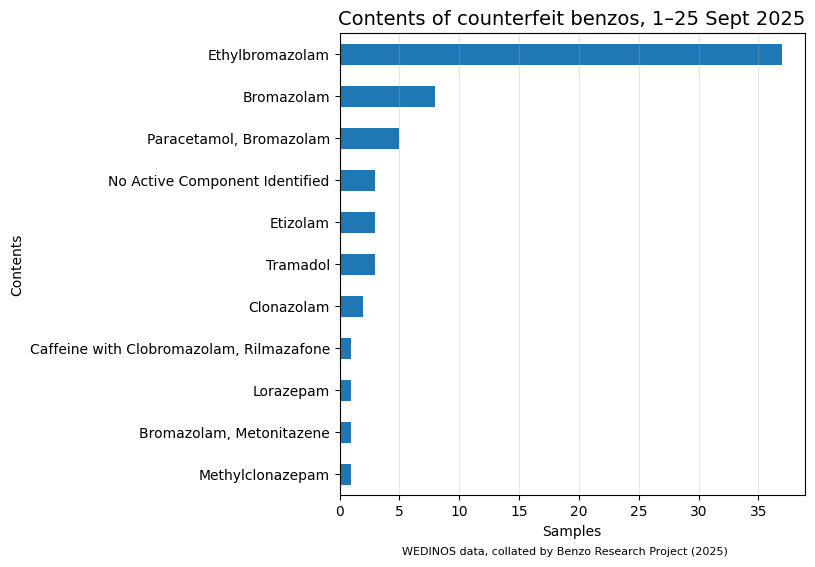

In [296]:
fig, ax = subplots(figsize=(6, 6))
ax.title.set_text('Contents of counterfeit benzos, 1–25 Sept 2025')
ax.title.set_fontsize(14)
counterfeitContents.sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Samples')
ax.set_ylabel('Contents')
ax.grid(axis='x',alpha=0.3)
text = fig.text(0.50, 0.01, 
            'WEDINOS data, collated by Benzo Research Project (2025)', 
            horizontalalignment='center', wrap=True, fontsize=8)

In [1]:
fig, ax = subplots(figsize=(6, 6))
ax.title.set_text('Contents of counterfeit benzos, 1 Jan–30 Sept 2025')
ax.title.set_fontsize(14)
counterfeitContents_all.head(20).sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Samples')
ax.set_ylabel('Contents')
ax.grid(axis='x',alpha=0.3)
text = fig.text(0.50, 0.01, 
            'WEDINOS data, collated by Benzo Research Project (2025)', 
            horizontalalignment='center', wrap=True, fontsize=8)

NameError: name 'subplots' is not defined

## Plots

In [418]:
plot_totals = np.array([
                            ['Sold as Benzos', total_benzo_intent],
                            ['Counterfeit', total_counterfeit_benzos],
                            ['Not Counterfeit', total_correct_benzos],
                            ['Unknown Intent', unknown_benzos],
                            ['Not Benzos', total_not_benzos]
                        ])
nitazene_totals = np.array([
                            ['Counterfeit opioids', totalnit-wantednit-cbenzo_count-unknownnit],
                            ['Counterfeit benzos', cbenzo_count],
                            ['Intended nitazenes', wantednit],
                            #['Metonitazene-containing benzos', cbenzo_meto_count],
                            ['Unknown intent', unknownnit]
                        ])
    

In [415]:
print(nitazene_totals)

[['Other counterfeits' '40']
 ['Counterfeit benzos' '5']
 ['Sold as nitazenes' '2']
 ['Unknown intent' '2']]


In [396]:
def monthly_benzo_rates(df, status, year):
    '''
    Creates a 12x3 numpy array with monthly counts of benzos sold as 'status' in the given year.
    Each row corresponds to a month, with the first column being the month number,
    the second column being the count of samples sold as 'status', and the third column being
    the total count of samples sold as benzos in that month.
    '''
    array = np.array([ #Month, Count of samples sold as status,                                                                                  Total samples sold as benzos,                                                               
                        [1, len(df[(df['date_received'].str.contains(f'Jan {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Jan {year}')) & (df['sold_as_benzo'] == '1')])],
                        [2, len(df[(df['date_received'].str.contains(f'Feb {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Feb {year}')) & (df['sold_as_benzo'] == '1')])],
                        [3, len(df[(df['date_received'].str.contains(f'Mar {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Mar {year}')) & (df['sold_as_benzo'] == '1')])],
                        [4, len(df[(df['date_received'].str.contains(f'Apr {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Apr {year}')) & (df['sold_as_benzo'] == '1')])],
                        [5, len(df[(df['date_received'].str.contains(f'May {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'May {year}')) & (df['sold_as_benzo'] == '1')])],
                        [6, len(df[(df['date_received'].str.contains(f'Jun {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Jun {year}')) & (df['sold_as_benzo'] == '1')])],
                        [7, len(df[(df['date_received'].str.contains(f'Jul {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Jul {year}')) & (df['sold_as_benzo'] == '1')])],
                        [8, len(df[(df['date_received'].str.contains(f'Aug {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Aug {year}')) & (df['sold_as_benzo'] == '1')])],
                        [9, len(df[(df['date_received'].str.contains(f'Sep {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Sep {year}')) & (df['sold_as_benzo'] == '1')])],
                        [10, len(df[(df['date_received'].str.contains(f'Oct {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Oct {year}')) & (df['sold_as_benzo'] == '1')])],
                        [11, len(df[(df['date_received'].str.contains(f'Nov {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Nov {year}')) & (df['sold_as_benzo'] == '1')])],
                        [12, len(df[(df['date_received'].str.contains(f'Dec {year}')) & (df['status'] == status) & (df['sold_as_benzo'] == '1')]), len(df[(df['date_received'].str.contains(f'Dec {year}')) & (df['sold_as_benzo'] == '1')])]
                    ])
    return array

monthly_data = monthly_benzo_rates(df_benzo, 'counterfeit', 2025)

In [397]:
def benzoMonthlyCounts(df, year, benzoname='Ethylbromazolam'):
    '''Produces a 12x4 array of the number of a given benzo found in samples tested per month in a given dataframe and year.
    Input dataframe, year (e.g., 2025), and the chosen benzo (default 'Ethylbromazolam', case sensitive!).'''
    array = np.array([ #Month, Count of samples sold as ethylbromazolam,                                                                 Total samples containing ethylbromazolam,                                                                                                                                                                                 Total samples sold as benzos,                                                                  
                        [1, len(df[(df['date_received'].str.contains(f'Jan {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Jan {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Jan {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Jan {year}')) & (df['sold_as_benzo'] == '1')])],
                        [2, len(df[(df['date_received'].str.contains(f'Feb {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Feb {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Feb {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Feb {year}')) & (df['sold_as_benzo'] == '1')])],
                        [3, len(df[(df['date_received'].str.contains(f'Mar {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Mar {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Mar {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Mar {year}')) & (df['sold_as_benzo'] == '1')])],
                        [4, len(df[(df['date_received'].str.contains(f'Apr {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Apr {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Apr {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Apr {year}')) & (df['sold_as_benzo'] == '1')])],
                        [5, len(df[(df['date_received'].str.contains(f'May {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'May {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'May {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'May {year}')) & (df['sold_as_benzo'] == '1')])],
                        [6, len(df[(df['date_received'].str.contains(f'Jun {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Jun {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Jun {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Jun {year}')) & (df['sold_as_benzo'] == '1')])],
                        [7, len(df[(df['date_received'].str.contains(f'Jul {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Jul {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Jul {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Jul {year}')) & (df['sold_as_benzo'] == '1')])],
                        [8, len(df[(df['date_received'].str.contains(f'Aug {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Aug {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Aug {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Aug {year}')) & (df['sold_as_benzo'] == '1')])],
                        [9, len(df[(df['date_received'].str.contains(f'Sep {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Sep {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Sep {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Sep {year}')) & (df['sold_as_benzo'] == '1')])],
                        [10, len(df[(df['date_received'].str.contains(f'Oct {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Oct {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Oct {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Oct {year}')) & (df['sold_as_benzo'] == '1')])],
                        [11, len(df[(df['date_received'].str.contains(f'Nov {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Nov {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Nov {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Nov {year}')) & (df['sold_as_benzo'] == '1')])],
                        [12, len(df[(df['date_received'].str.contains(f'Dec {year}')) & (df['intent'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Dec {year}')) & (df['major'].str.contains(benzoname))]) + len(df[(df['date_received'].str.contains(f'Dec {year}')) & (df['minor'].str.contains(benzoname))]), len(df[(df['date_received'].str.contains(f'Dec {year}')) & (df['sold_as_benzo'] == '1')])]
                    ])
    return array
ethylmonthly = benzoMonthlyCounts(df_benzo, 2025, benzoname='Ethylbromazolam')
bromazmonthly = benzoMonthlyCounts(df_benzo, 2025, benzoname='Bromazolam')

In [398]:
df_benzo.loc[df_benzo['major'] == "Ethylbromazolam"]

,date_received,postcode,intent,label,colour,form,consumption_method,effects,major,minor,latitude,longitude,sold_as_benzo,status
W067541,12 Aug 2025,YO23,Xanax,Xanax,White,Tablet,Not Stated,Not Stated,Ethylbromazolam,,53.914883,-1.167233,1,counterfeit
W067516,12 Aug 2025,PE2,Diazepam,Galenika Bensedin,White,Tablet,Not Stated,Not Stated,Ethylbromazolam,,52.555250,-0.266567,1,counterfeit
000235577,12 Aug 2025,NP12,valium,valium,Blue,Tablet,Oral,Not Stated,Ethylbromazolam,,51.667800,-3.207500,1,counterfeit
W067811,12 Aug 2025,G13,Diazepam,Not Stated,Blue,Tablet,Oral,"Relaxed, Memory Loss, Confusion",Ethylbromazolam,,55.893500,-4.348000,1,counterfeit
W067673,07 Aug 2025,TS23,Diazepam,Diazepam,Blue,Tablet,Oral,Not Stated,Ethylbromazolam,,54.596667,-1.268400,1,counterfeit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W069346,26 Sep 2025,WS15,Xanax,Alprazolam Kern,White,Tablet,Oral,No Effect,Ethylbromazolam,,52.757663,-1.903044,1,counterfeit
W069296,25 Sep 2025,RG27,DIAZEPAM,Not Stated,Blue,Tablet,Not Stated,Not Stated,Ethylbromazolam,,51.304967,-0.951079,1,counterfeit
W069281,25 Sep 2025,N20,diazepam 10mg,accord diazepam 10mg,Blue,Tablet,Oral,"Relaxed, Memory Loss",Ethylbromazolam,,51.633300,-0.183320,1,counterfeit
W069297,25 Sep 2025,RG27,XANAX,Not Stated,White,Tablet,Not Stated,Not Stated,Ethylbromazolam,,51.304967,-0.951079,1,counterfeit


In [399]:
print(ethylmonthly.shape)

(12, 4)


In [400]:
print(f'{sum(ethylmonthly[:,1])} samples were sold as ethylbromazolam between Jan and Sep 2025.')

0 samples were sold as ethylbromazolam between Jan and Sep 2025.


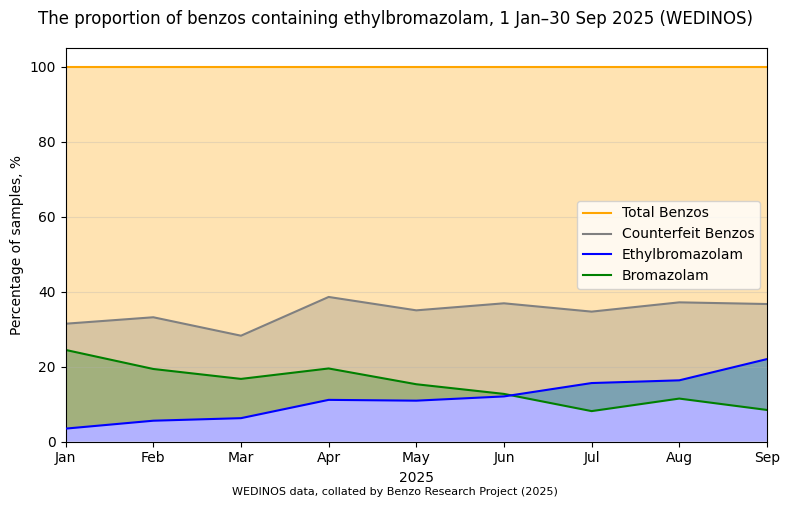

In [419]:
data_jan_sep = monthly_data[monthly_data[:,0] <= 9]
ethyljan_sep = ethylmonthly[ethylmonthly[:,0] <= 9]
bromazjan_sep = bromazmonthly[bromazmonthly[:,0] <= 9]
fig, ax = subplots(figsize=(8, 5))
fig.suptitle('The proportion of benzos containing ethylbromazolam, 1 Jan–30 Sep 2025 (WEDINOS)')
ax.fill_between(ethyljan_sep[:,0], 0, ethyljan_sep[:,2]/ethyljan_sep[:,3]*100, facecolor='blue', alpha=0.3)
ax.fill_between(ethyljan_sep[:,0], ethyljan_sep[:,2]/ethyljan_sep[:,3]*100, ethyljan_sep[:,3]/ethyljan_sep[:,3]*100, facecolor='orange', alpha=0.3)
ax.fill_between(ethyljan_sep[:,0], ethyljan_sep[:,2]/ethyljan_sep[:,3]*100, bromazjan_sep[:,2]/bromazjan_sep[:,3]*100, facecolor='green', alpha=0.3)
ax.fill_between(ethyljan_sep[:,0], ethyljan_sep[:,2]/ethyljan_sep[:,3]*100, data_jan_sep[:,1]/data_jan_sep[:,2]*100, facecolor='grey', alpha=0.3)

ax.plot(ethyljan_sep[:,0], ethyljan_sep[:,3]/ethyljan_sep[:,3]*100, label ='Total Benzos', color='orange')
ax.plot(data_jan_sep[:,0], data_jan_sep[:,1]/data_jan_sep[:,2]*100, label ='Counterfeit Benzos', color='gray')
ax.plot(ethyljan_sep[:,0], ethyljan_sep[:,2]/ethyljan_sep[:,3]*100, label ='Ethylbromazolam', color='blue', zorder=3)
ax.plot(bromazjan_sep[:,0], bromazjan_sep[:,2]/bromazjan_sep[:,3]*100, label ='Bromazolam', color='green')
ax.set_ylabel('Percentage of samples, %')
ax.set_xlim(1, 9)
ax.set_ylim(0)
ax.set_xticks(ethyljan_sep[:,0])
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'])
ax.grid(axis='y',alpha=0.3)
ax.set_xlabel('2025')
ax.legend(loc='right')
text = fig.text(0.50, 0.01, 
            'WEDINOS data, collated by Benzo Research Project (2025)', 
            horizontalalignment='center', wrap=True, fontsize=8)
fig.tight_layout()

In [402]:
monthly_data[:,0]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [403]:
plot_totals[:,1].astype(int)

array([1932,  669, 1258,    5,   55])

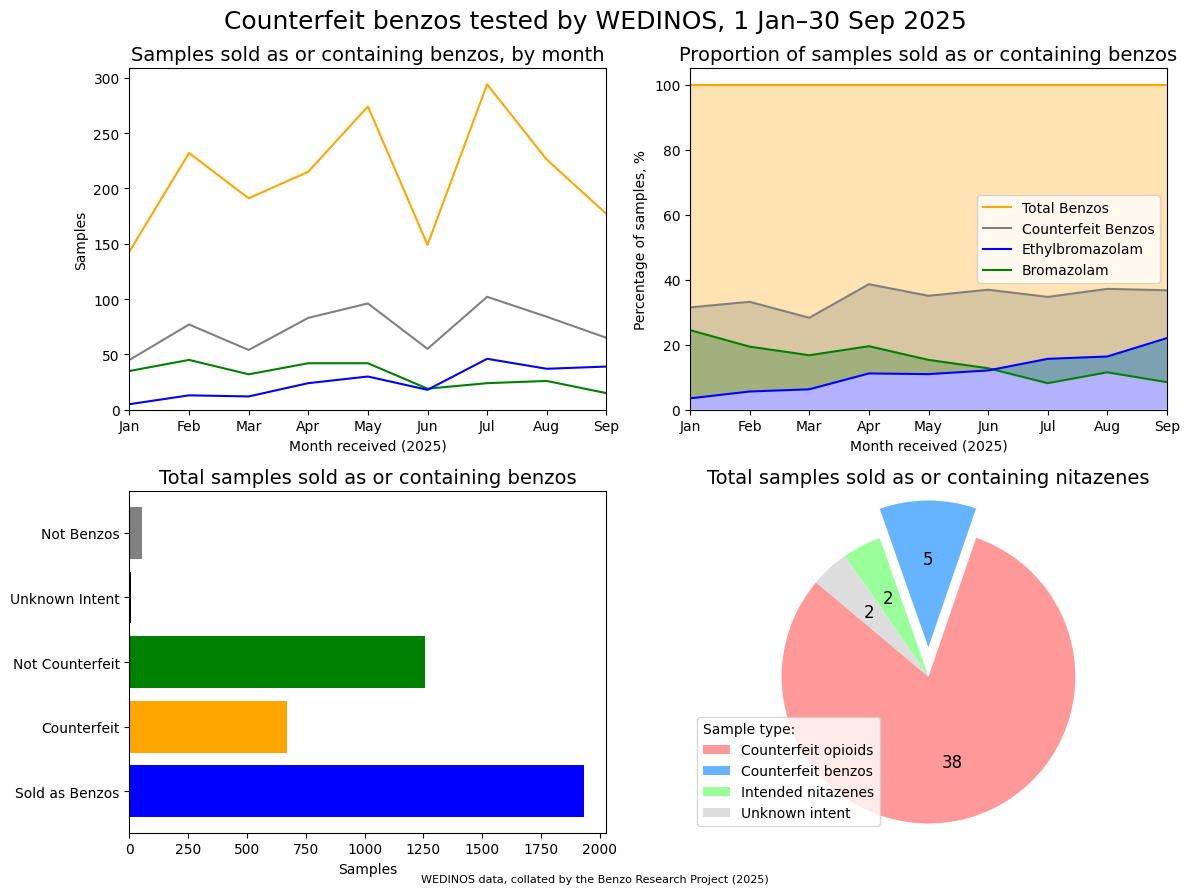

In [420]:
data_jan_sep = monthly_data[monthly_data[:,0] <= 9]
fig, (ax, ax1) = subplots(2, 2, figsize=(12, 9))
fig.suptitle('Counterfeit benzos tested by WEDINOS, 1 Jan–30 Sep 2025', fontsize=18)
ax[0].set_title('Samples sold as or containing benzos, by month', fontsize=14)
ax[0].plot(data_jan_sep[:,0], data_jan_sep[:,1], label ='Counterfeit Benzos', color='gray')
ax[0].plot(data_jan_sep[:,0], data_jan_sep[:,2], label ='Total Benzos', color='orange')
ax[0].plot(bromazjan_sep[:,0], bromazjan_sep[:,2], label ='Bromazolam', color='green')
ax[0].plot(ethyljan_sep[:,0], ethyljan_sep[:,2], label ='Ethylbromazolam', color='blue')
ax[0].set_ylabel('Samples')
ax[0].set_xlim(1, 9)
ax[0].set_ylim(0)
ax[0].set_xlabel('Month received (2025)')
ax[0].set_xticks(data_jan_sep[:,0])
ax[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'])
#ax[0].legend()
ax[1].set_title('Proportion of samples sold as or containing benzos', fontsize=14)
ax[1].fill_between(ethyljan_sep[:,0], 0, ethyljan_sep[:,2]/ethyljan_sep[:,3]*100, facecolor='blue', alpha=0.3)
ax[1].fill_between(ethyljan_sep[:,0], ethyljan_sep[:,2]/ethyljan_sep[:,3]*100, ethyljan_sep[:,3]/ethyljan_sep[:,3]*100, facecolor='orange', alpha=0.3)
ax[1].fill_between(ethyljan_sep[:,0], ethyljan_sep[:,2]/ethyljan_sep[:,3]*100, bromazjan_sep[:,2]/bromazjan_sep[:,3]*100, facecolor='green', alpha=0.3)
ax[1].fill_between(ethyljan_sep[:,0], ethyljan_sep[:,2]/ethyljan_sep[:,3]*100, data_jan_sep[:,1]/data_jan_sep[:,2]*100, facecolor='grey', alpha=0.3)
ax[1].plot(ethyljan_sep[:,0], ethyljan_sep[:,3]/ethyljan_sep[:,3]*100, label ='Total Benzos', color='orange')
ax[1].plot(data_jan_sep[:,0], data_jan_sep[:,1]/data_jan_sep[:,2]*100, label ='Counterfeit Benzos', color='gray')
ax[1].plot(ethyljan_sep[:,0], ethyljan_sep[:,2]/ethyljan_sep[:,3]*100, label ='Ethylbromazolam', color='blue', zorder=3)
ax[1].plot(bromazjan_sep[:,0], bromazjan_sep[:,2]/bromazjan_sep[:,3]*100, label ='Bromazolam', color='green')
ax[1].set_ylabel('Percentage of samples, %')
ax[1].set_xlim(1, 9)
ax[1].set_ylim(0)
ax[1].set_xlabel('Month received (2025)')
ax[1].set_xticks(data_jan_sep[:,0])
ax[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'])
ax[1].legend()

ax1[0].set_title('Total samples sold as or containing benzos', fontsize=14)
ax1[0].barh(plot_totals[:,0], plot_totals[:,1].astype(int), color=['blue', 'orange', 'green', 'black', 'grey'])
ax1[0].set_xlabel('Samples')

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return '{v:d}'.format(v=val)
    return my_format

ax1[1].set_title('Total samples sold as or containing nitazenes', fontsize=14)
ax1[1].pie(nitazene_totals[:,1].astype(int),
           #labels=nitazene_totals[:3,0], 
           explode=[0, 0.2, 0, 0],
           autopct=autopct_format(nitazene_totals[:,1].astype(int)), #autopct='%1.1f%%' for percentages
           startangle=140, 
           colors=['#ff9999','#66b3ff', '#99ff99', '#dddddd'], 
           textprops={'fontsize': 12})

ax1[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax1[1].legend(nitazene_totals[:,0], loc='lower left', title='Sample type:                  ')
text = fig.text(0.50, 0.01, 
            'WEDINOS data, collated by the Benzo Research Project (2025)', 
            horizontalalignment='center', wrap=True, fontsize=8)
fig.tight_layout()


In [374]:
nitazene_totals[:3,1].astype(int)

array([41,  5,  1])

In [358]:
nitazene_totals[:3,0]

array(['Other counterfeits', 'Counterfeit benzos', 'Sold as nitazenes'],
      dtype='<U30')

In [330]:
msjb_count=0
total=0
for idx, row in df_benzo.iterrows():
    if ('bensedin' in str.lower(row['intent'])) or ('msj' in str.lower(row['intent'])) or ('benzodine' in str.lower(row['intent'])):
        msjb_count+=1
        total+=1
    else:
        total+=1
print(msjb_count,'intended as MSJ/Bensedin/Benzodine')
print(100*msjb_count/total,'%')

47 intended as MSJ/Bensedin/Benzodine
2.365374937091092 %


## Processing cleaned WEDINOS data

In [1]:
def find_benzos_in_cleaned(df_benzo):
    for idx, row in df_benzo.iterrows():
        if any(substring in str.lower(row['Purchase']) for substring in benzo_substring_list):
            sold_as_benzo='1'
            try: # try-except to avoid errors with missing testing data
                if (str.lower(row['Result 1']) in str.lower(row['Purchase'])) or (str.lower(row['Purchase']) in str.lower(row['Result 1'])):
                    status='not counterfeit'
                elif ('unable to identify' in str.lower(row['Result 1'])):
                    status='inconclusive'
                # checking diazepam spellings
                elif any(substring in str.lower(row['Purchase']) for substring in diazepam_substring_list):
                    if ('diazepam' in str.lower(row['Result 1'])):
                        status='not counterfeit'
                    else:
                        status='counterfeit'
                # checking xanax spellings
                elif any(substring in str.lower(row['Purchase']) for substring in alprazolam_substring_list):
                    if ('alprazolam' in str.lower(row['Result 1'])):
                        status='not counterfeit'    
                    else:
                        status='counterfeit'
                # checking clonazepam spellings
                elif any(substring in str.lower(row['Purchase']) for substring in clonazepam_substring_list):
                    if ('clonazepam' in str.lower(row['Result 1'])):
                        status='not counterfeit'
                    else:
                        status='counterfeit'
                elif ('benzo' in str.lower(row['Purchase'])):
                    if any(substring in str.lower(row['Purchase']) for substring in diazepam_substring_list):
                        if ('diazepam' in str.lower(row['Result 1'])):
                            status='not counterfeit'
                        else:
                            status='counterfeit'
                    elif any(substring in str.lower(row['Purchase']) for substring in benzo_substring_list):
                        status='not counterfeit'
                    else:
                        status='counterfeit'
                else:
                    status='counterfeit'
                    #print(row['intent'],': ',row['major'],'with',row['minor'])
            except:
                status='inconclusive'
        else:
            sold_as_benzo='0'
        
        df_benzo.loc[idx,'sold_as_benzo'] = sold_as_benzo
        df_benzo.loc[idx,'status'] = status

    return df_benzo


In [22]:
aug_cleaned = pd.read_excel('/Users/ajmartin/Downloads/WEDINOS August 2025.xlsx')

In [23]:
augCleaned = find_benzos_in_cleaned(aug_cleaned)
augCleaned

,Key,CtlReceipt,Purchase,SampleForm,Colour,RpAge,RpGender,Postcode,Country,Consumption,...,Result 2,Result 3,Result 4,Result 5,Result 6,Result 7,Result 8,Result 9,sold_as_benzo,status
0,57849,2025-08-01,Diazepam,Tablet,Yellow,Not Stated,Male,TN16,England,Not Stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,not counterfeit
1,57850,2025-08-01,Cocaine,Powder,White,50,Male,EH21,Scotland,Not Stated,...,Norcocaine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,not counterfeit
2,57851,2025-08-01,Tramadol,Tablet,White,40,Female,BA6,England,Oral,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,not counterfeit
3,57852,2025-08-01,Tramadol,Tablet,White,40,Female,BA6,England,Oral,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,not counterfeit
4,57853,2025-08-01,Ketamine,Powder,White,Not Stated,Male,CF48,Wales,Not Stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,not counterfeit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,58592,2025-08-28,Alprazolam,Tablet,White,23,Not Stated,PH22,Scotland,Not Stated,...,Bromazolam,Tramadol,NaN,NaN,NaN,NaN,NaN,NaN,1,counterfeit
651,58593,2025-08-28,MDMA,Tablet,NaN,23,Not Stated,PH22,Scotland,Not Stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,counterfeit
652,58594,2025-08-28,Diazepam,Tablet,Blue,43,Male,SK13,England,Not Stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,not counterfeit
653,58595,2025-08-28,Diazepam,Tablet,White,26,Male,BS43,England,Not Stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,not counterfeit


36.33587786259542% of samples in August 2025 were sold as benzos (238 out of 655), of which:
- 145 contained what they were sold as (60.924369747899156%)
- 93 were counterfeit (39.075630252100844%)


Text(0.5, 1.0, 'Samples intended/sold as benzos tested by WEDINOS, August 2025')

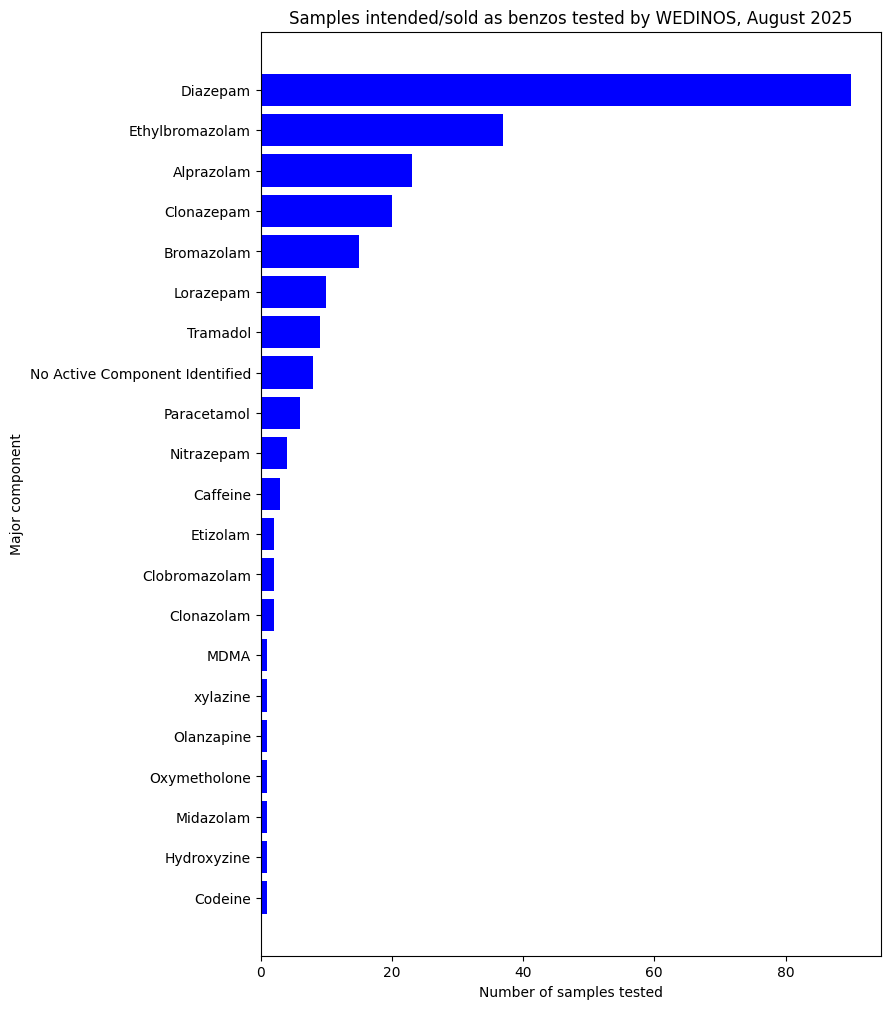

In [41]:
print(f'{100*len(augCleaned[augCleaned["sold_as_benzo"] == "1"])/len(augCleaned)}% of samples in August 2025 were sold as benzos ({len(augCleaned[augCleaned["sold_as_benzo"] == "1"])} out of {len(augCleaned)}), of which:')
print(f'- {len(augCleaned[(augCleaned["sold_as_benzo"] == "1") & (augCleaned["status"] == "not counterfeit")])} contained what they were sold as ({100*len(augCleaned[(augCleaned["sold_as_benzo"] == "1") & (augCleaned["status"] == "not counterfeit")])/len(augCleaned[augCleaned["sold_as_benzo"] == "1"])}%)')
print(f'- {len(augCleaned[(augCleaned["sold_as_benzo"] == "1") & (augCleaned["status"] == "counterfeit")])} were counterfeit ({100*len(augCleaned[(augCleaned["sold_as_benzo"] == "1") & (augCleaned["status"] == "counterfeit")])/len(augCleaned[augCleaned["sold_as_benzo"] == "1"])}%)')
fig, ax = subplots(figsize=(8, 12))
ax.barh(augCleaned[augCleaned["sold_as_benzo"] == "1"]["Result 1"].value_counts().index, augCleaned[augCleaned["sold_as_benzo"] == "1"]["Result 1"].value_counts().values, color='blue')
ax.set_ylabel('Major component')
ax.set_xlabel('Number of samples tested')
fig.gca().invert_yaxis()
ax.set_title('Samples intended/sold as benzos tested by WEDINOS, August 2025')

## Tests (ignore)

In [22]:
from datetime import datetime
for idx, row in df.iterrows():
    df.at[idx, row['date_received']] = datetime.strptime(row['date_received'], '%d %b %Y').date()
print(df['date_received'])

W059957      26 Nov 2024
000230437    21 Nov 2024
W059740      19 Nov 2024
000233224    14 Nov 2024
W059583      14 Nov 2024
                ...     
W046706      10 Jan 2024
W044688      04 Jan 2024
000040892    04 Jan 2024
W044755      22 Dec 2023
W044679      21 Dec 2023
Name: date_received, Length: 144, dtype: object


In [34]:
timeex = datetime.strptime('26 Nov 2024', '%d %b %Y').date()
int(timeex.strftime('%d%b%Y'))


ValueError: invalid literal for int() with base 10: '26Nov2024'

In [35]:
datetime.strptime('Feb','%b').tm_mon

AttributeError: 'datetime.datetime' object has no attribute 'tm_mon'

In [40]:
import calendar
astring = '26 Nov 2024'
def month_number(astring):
    # Convert the string to a datetime object
    month = datetime.strptime(astring, '%d %b %Y').month
    return month
type(month_number(astring))

int

In [50]:
year2 = pd.to_datetime(astring).year
year2

2024

In [71]:
for idx, row in df.iterrows():
    print(row['date_received'])
    df.loc[idx,'date_received'] = pd.Timestamp(row['date_received'])
numdate = row['date_received']
type(df['date_received'].unique()[0])

2024-11-26 00:00:00
2024-11-21 00:00:00
2024-11-19 00:00:00
2024-11-14 00:00:00
2024-11-14 00:00:00
2024-11-20 00:00:00
2024-11-12 00:00:00
2024-11-05 00:00:00
2024-11-05 00:00:00
2024-10-22 00:00:00
2024-10-15 00:00:00
2024-10-11 00:00:00
2024-10-01 00:00:00
2024-09-03 00:00:00
2024-08-28 00:00:00
2024-08-28 00:00:00
2024-08-23 00:00:00
2024-08-20 00:00:00
2024-08-20 00:00:00
2024-08-20 00:00:00
2024-08-20 00:00:00
2024-08-15 00:00:00
2024-08-15 00:00:00
2024-08-07 00:00:00
2024-08-01 00:00:00
2024-08-01 00:00:00
2024-07-29 00:00:00
2024-07-23 00:00:00
2024-07-22 00:00:00
2024-07-16 00:00:00
2024-07-16 00:00:00
2024-07-11 00:00:00
2024-07-09 00:00:00
2024-07-09 00:00:00
2024-07-09 00:00:00
2024-07-02 00:00:00
2024-07-02 00:00:00
2024-07-02 00:00:00
2024-06-18 00:00:00
2024-06-18 00:00:00
2024-06-18 00:00:00
2024-06-18 00:00:00
2024-06-11 00:00:00
2024-06-11 00:00:00
2024-06-10 00:00:00
2024-06-10 00:00:00
2024-06-10 00:00:00
2024-06-07 00:00:00
2024-06-04 00:00:00
2024-06-03 00:00:00


pandas._libs.tslibs.timestamps.Timestamp